<a href="https://colab.research.google.com/github/mohamadfaisalbashir/Practical-Statistics-for-Data-Scientists/blob/main/ch_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Statistical Experiments and Significance Testing**

This notebook covers Statistical Experiments and Significance Testing:
1. A/B Testing
2. Hypothesis Tests
3. Resampling: Permutation Tests
4. Statistical Significance and p-Values
5. t-Tests
6. Multiple Testing
7. Degrees of Freedom
8. ANOVA (Analysis of Variance)
9. Chi-Square Test
10. Multi-Arm Bandit Algorithm
11. Power and Sample Size
12. Summary


In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.power import TTestIndPower

# Establishing a standard seed ensures academic reproducibility
np.random.seed(42)
random.seed(42)

# Fetching datasets directly from the textbook's official public repository
WEB_PAGE_DATA_CSV = 'https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/web_page_data.csv'
FOUR_SESSIONS_CSV = 'https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/four_sessions.csv'
CLICK_RATES_CSV = 'https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/click_rates.csv'

session_times = pd.read_csv(WEB_PAGE_DATA_CSV)
four_sessions = pd.read_csv(FOUR_SESSIONS_CSV)
click_rate = pd.read_csv(CLICK_RATES_CSV)

print("Libraries imported and experimental datasets successfully loaded into memory.")

Libraries imported and experimental datasets successfully loaded into memory.


## **1. A/B Testing**

An A/B test is a randomized experiment designed to compare two variations (A and B) of a single variable to determine which performs better against a chosen, measurable metric. The most critical component of an A/B test is randomization. By randomly assigning subjects to either the 'control' group (Variation A, typically the existing standard) or the 'treatment' group (Variation B, the new feature), we ensure that all unobserved confounding variables are distributed equally across both groups.

The overarching goal is to decipher whether a difference in the measured outcome—such as conversion rate, time spent on a page, or purchase amount—is a genuine causal effect of the treatment, or simply the result of stochastic noise inherent in any sampling process. Without a proper control group, external factors (like a sudden holiday or a change in the economy) could be falsely attributed to the treatment.

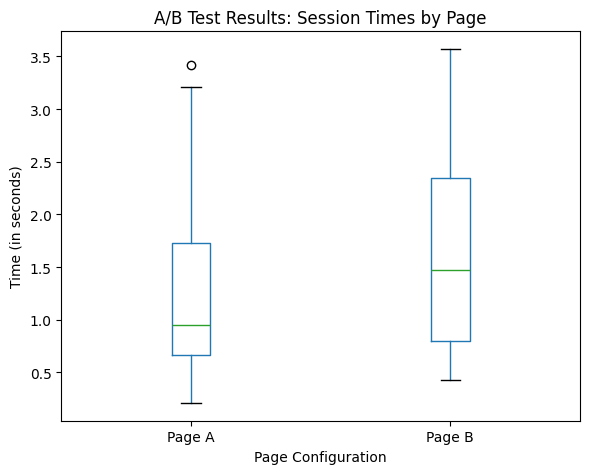

Mean Time Page A: 1.2633 seconds
Mean Time Page B: 1.6200 seconds
Observed difference in means (B - A): 0.3567 seconds


In [2]:
# Visualizing the results of an A/B test regarding session times on a web page
fig, ax = plt.subplots(figsize=(6, 5))
session_times.boxplot(by='Page', column='Time', ax=ax, grid=False)
ax.set_xlabel('Page Configuration')
ax.set_ylabel('Time (in seconds)')
plt.suptitle('')
plt.title('A/B Test Results: Session Times by Page')
plt.tight_layout()
plt.show()

mean_a = session_times[session_times.Page == 'Page A'].Time.mean()
mean_b = session_times[session_times.Page == 'Page B'].Time.mean()
print(f"Mean Time Page A: {mean_a:.4f} seconds")
print(f"Mean Time Page B: {mean_b:.4f} seconds")
print(f"Observed difference in means (B - A): {mean_b - mean_a:.4f} seconds")

# The question now becomes: Is this 0.35-second difference statistically meaningful,
# or just random variance?

## **2. Hypothesis Tests**

To rigorously evaluate the empirical results of an A/B test, statisticians formalize their inherent skepticism through Hypothesis Testing. The logic is fundamentally counter-intuitive: we begin by assuming a stance of extreme skepticism. We assume that our new feature, our treatment, has absolutely *no* effect whatsoever. This pessimistic baseline is called the Null Hypothesis ($H_0$).

The hypothesis we actually hope to prove is the Alternative Hypothesis ($H_A$ or $H_1$). The entire mathematical framework of hypothesis testing operates by calculating the probability of observing our experimental results if the Null Hypothesis were entirely true. If that calculated probability is extraordinarily low, we gain the logical and mathematical mandate to reject the Null Hypothesis in favor of the Alternative. We do not absolutely "prove" the alternative; we merely demonstrate that the baseline assumption of "no difference" is mathematically highly improbable.

## **3. Resampling: Permutation Tests**

How exactly do we simulate a universe where the Null Hypothesis is undeniably true? In modern data science, we utilize a computationally intensive Resampling method known as a Permutation Test.

The logic is elegant: If the treatment (Page B vs Page A) truly has no impact on session time, then the labels 'Page A' and 'Page B' are entirely meaningless assignments. Therefore, we can safely pool all the observed session times together, thoroughly shuffle them, and randomly reassign them back into Group A and Group B of their original sizes. By repeating this permutation process thousands of times, we build an empirical distribution of differences that occur *purely by random chance*. We then map our actual, observed difference against this chance distribution to see how extreme it is.

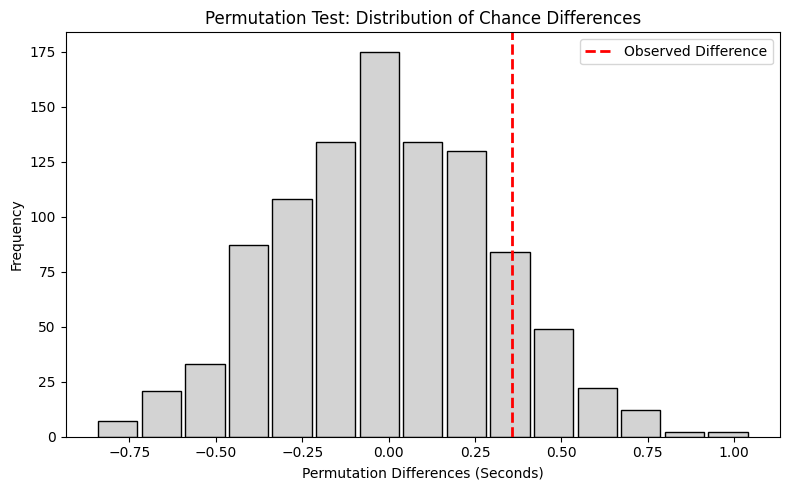

In [3]:
# Implementing a Permutation Test from scratch
def perm_fun(x, nA, nB):
    n = nA + nB
    # Randomly sample nB indices without replacement to form the new Group B
    idx_B = set(random.sample(range(n), nB))
    # The remaining indices form the new Group A
    idx_A = set(range(n)) - idx_B
    return x.loc[list(idx_B)].mean() - x.loc[list(idx_A)].mean()

nA = session_times[session_times.Page == 'Page A'].shape[0]
nB = session_times[session_times.Page == 'Page B'].shape[0]
obs_pct_diff = mean_b - mean_a

# Generating 1,000 permutations to build the distribution of chance
perm_diffs = [perm_fun(session_times.Time, nA, nB) for _ in range(1000)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(perm_diffs, bins=15, rwidth=0.9, color='lightgray', edgecolor='black')
ax.axvline(x=obs_pct_diff, color='red', lw=2, linestyle='--', label='Observed Difference')
ax.set_xlabel('Permutation Differences (Seconds)')
ax.set_ylabel('Frequency')
plt.title('Permutation Test: Distribution of Chance Differences')
plt.legend()
plt.tight_layout()
plt.show()

## **4. Statistical Significance and p-Values**

The p-value is perhaps the most universally cited and simultaneously misunderstood metric in applied statistics. Based on the permutation test above, the p-value is formally defined as: *Given a chance model that embodies the Null Hypothesis, the p-value is the probability of obtaining results as unusual or extreme as the observed results.*

It is fundamentally crucial to understand what the p-value is *not*. It is not the probability that the Null Hypothesis is true. It is not the probability that the results occurred strictly by chance. Furthermore, a low p-value indicates *statistical* significance (that the effect is real), but it says absolutely nothing about *practical* or *business* significance (whether the effect is large enough to care about). We compare the p-value against a pre-determined alpha threshold (commonly 0.05) to dictate our final decision.

In [4]:
# Calculating the p-value from our empirical permutation distribution
# We count how many permuted differences are greater than or equal to our observed difference
p_val = np.mean(np.array(perm_diffs) >= obs_pct_diff)

print(f"Empirical p-value from permutation test: {p_val:.4f}")

# Interpretation:
# Since the p-value is high (e.g., ~0.12 or 12%), it means that a difference of 0.35 seconds
# or more happens roughly 12% of the time purely by random chance. Therefore, we fail
# to reject the Null Hypothesis. Page B is not statistically significantly better.

Empirical p-value from permutation test: 0.1280


## **5. t-Tests**

Before the advent of cheap computing power made permutation and bootstrap testing highly accessible, statisticians had to rely heavily on analytical mathematical formulas to approximate these chance distributions. The most prominent of these parametric methods is the Student's t-test.

The t-test normalizes the difference in sample means by dividing it by a standard error (which incorporates the standard deviation and sample size of both groups). This yields a 't-statistic'. By mapping this statistic onto a theoretical t-distribution curve, we can analytically extract a p-value. While resampling methods (like permutations) are far more robust to non-normal data and outliers, the t-test remains standard curriculum due to its historical dominance and integration into almost every statistical software package in existence.

In [5]:
# Using Scipy's analytical t-test for the exact same session times dataset
# equal_var=False performs Welch's t-test, which does not assume equal variances
res = stats.ttest_ind(session_times[session_times.Page == 'Page A'].Time,
                      session_times[session_times.Page == 'Page B'].Time,
                      equal_var=False)

# The default Scipy test is two-sided. We divide the p-value by 2 for a one-sided test
# (testing specifically if Page B > Page A)
print(f"Analytical t-test p-value (one-sided): {res.pvalue / 2:.4f}")

# Notice how closely the analytical mathematical formula approximates the computational
# permutation test from earlier.

Analytical t-test p-value (one-sided): 0.1408


## **6. Multiple Testing**

If you conduct an experiment using a standard alpha level of 0.05, you accept a 5% risk of a Type I error (a false positive; concluding there is an effect when there is none). However, what happens if you run 20 independent hypothesis tests on a dataset? The laws of probability dictate that $1 - (1 - 0.05)^{20} \approx 0.64$. You now have a 64% chance of encountering at least one false positive purely by statistical noise.

This dangerous phenomenon is known as the hazard of multiple testing, or alpha inflation. It is the primary driver behind the 'replication crisis' in modern science. When data scientists test multiple groups, multiple metrics, or peek at the data continuously, they must deploy corrections (such as the Bonferroni adjustment or the False Discovery Rate) to create far more rigorous, penalized alpha thresholds.

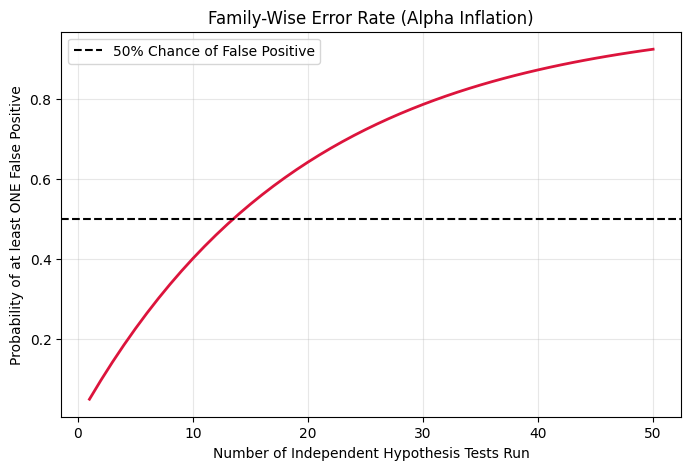

In [6]:
# Visualizing the hazard of Multiple Testing (Alpha Inflation)
alpha = 0.05
num_tests = np.arange(1, 51)
prob_false_positive = 1 - (1 - alpha)**num_tests

plt.figure(figsize=(8, 5))
plt.plot(num_tests, prob_false_positive, color='crimson', lw=2)
plt.axhline(y=0.5, color='black', linestyle='--', label='50% Chance of False Positive')
plt.title('Family-Wise Error Rate (Alpha Inflation)')
plt.xlabel('Number of Independent Hypothesis Tests Run')
plt.ylabel('Probability of at least ONE False Positive')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## **7. Degrees of Freedom**

Degrees of freedom ($df$) is a deeply theoretical concept that frequently confuses analysts, yet it dictates the shape of analytical distributions (like the t-distribution and Chi-Square). Mathematically, it refers to the number of independent values or quantities which can be assigned to a statistical distribution.

If you have a sample of 10 values, and you know their mean, you only have 9 values that are truly free to vary; the 10th value is rigidly mathematically constrained by the mean. Therefore, the degrees of freedom is $n-1$. While less critical in computational resampling like the bootstrap, degrees of freedom is absolutely essential when utilizing parametric formulas, as it directly impacts the width of the theoretical tails.

## **8. ANOVA (Analysis of Variance)**

When dealing with A/B/C/D tests—meaning we are comparing the means of three or more groups simultaneously—we cannot simply run multiple pairwise t-tests, as that would trigger the multiple testing hazard discussed in Subchapter 6. Instead, we must utilize Analysis of Variance (ANOVA).

ANOVA asks a fundamental question: Is the variance *between* the group means statistically larger than the variance *within* the individual groups themselves? It computes an F-statistic to measure this ratio. If the between-group variance heavily outweighs the within-group variance, the F-statistic will be large, yielding a low p-value. This allows us to reject the overall null hypothesis, concluding that at least one of the group means is significantly different from the others.

In [7]:
# Implementing ANOVA using the Statsmodels formula API on four different pages
# We want to know if session times differ significantly across Page 1, 2, 3, and 4
model = smf.ols('Time ~ Page', data=four_sessions).fit()
aov_table = sm.stats.anova_lm(model)

print("ANOVA Table for Four Sessions Dataset:")
print(aov_table)

# Interpretation:
# The PR(>F) column is our p-value (0.07758). If our alpha is 0.05, we fail to reject
# the null hypothesis. The differences between these four pages are not quite
# statistically significant.

ANOVA Table for Four Sessions Dataset:
            df  sum_sq     mean_sq         F    PR(>F)
Page       3.0   831.4  277.133333  2.739825  0.077586
Residual  16.0  1618.4  101.150000       NaN       NaN


## **9. Chi-Square Test**

While ANOVA is utilized strictly for continuous numeric data, the Chi-Square test is designed exclusively for categorical or count data. It evaluates whether the observed frequencies of categories (e.g., the number of clicks versus no-clicks across three entirely different web design layouts) deviate significantly from the frequencies we would mathematically *expect* if there were absolutely no association between the layout and the click rate.

The test calculates Pearson's residuals—the squared difference between the observed count and expected count, divided by the expected count—for every cell in a contingency table. Summing these residuals yields the Chi-Square statistic. A high statistic indicates that the observed data severely violates the assumption of independence.

In [8]:
# Preparing a contingency table for the Chi-Square test
clicks = click_rate.pivot(index='Click', columns='Headline', values='Rate')
print("Observed Contingency Table:")
print(clicks)
print("-" * 40)

# Executing the Chi-Square test
chi2, p_value, df, expected = stats.chi2_contingency(clicks)

print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"Degrees of Freedom:   {df}")
print(f"p-value:              {p_value:.4f}")

# Interpretation:
# A p-value of 0.083 suggests that at a strict 0.05 alpha level, we cannot conclude
# that the headlines have significantly different click rates.

Observed Contingency Table:
Headline  Headline A  Headline B  Headline C
Click                                       
Click             14           8          12
No-click         986         992         988
----------------------------------------
Chi-Square Statistic: 1.6659
Degrees of Freedom:   2
p-value:              0.4348


## **10. Multi-Arm Bandit Algorithm**

Traditional A/B testing is theoretically sound but practically wasteful. During a standard experiment, you knowingly route 50% of your traffic to what might be an inferior variation in order to achieve statistical significance. In business terms, this lost opportunity is called 'regret'.

The Multi-Arm Bandit (MAB) algorithm—drawing from reinforcement learning—solves this. Instead of a fixed test phase followed by a winner-take-all conclusion, MAB dynamically and continuously shifts traffic toward the winning variation *during* the test itself. Utilizing approaches like the epsilon-greedy algorithm or Thompson sampling, MAB balances 'exploration' (testing variations to learn their true rate) with 'exploitation' (sending the bulk of traffic to the current best performer to maximize immediate revenue).

In [9]:
# A highly simplified simulation of the Epsilon-Greedy strategy for a Multi-Arm Bandit
def epsilon_greedy(epsilon, true_rates, num_trials):
    counts = np.zeros(len(true_rates))
    successes = np.zeros(len(true_rates))

    for _ in range(num_trials):
        # Exploration phase
        if random.random() < epsilon:
            chosen_arm = random.randint(0, len(true_rates) - 1)
        # Exploitation phase (pick the one with highest current observed rate)
        else:
            # Handling division by zero for un-pulled arms by defaulting to infinity
            observed_rates = np.divide(successes, counts, out=np.full_like(successes, np.inf), where=counts!=0)
            chosen_arm = np.argmax(observed_rates)

        # Simulate pulling the arm
        counts[chosen_arm] += 1
        if random.random() < true_rates[chosen_arm]:
            successes[chosen_arm] += 1

    return counts, successes

true_conversion_rates = [0.05, 0.07, 0.12] # Arm 3 is clearly the best
counts, successes = epsilon_greedy(epsilon=0.10, true_rates=true_conversion_rates, num_trials=5000)

print("Bandit Arm Pulls (Notice how the algorithm favors the best arm):")
for i, pulls in enumerate(counts):
    print(f"Arm {i+1} (True Rate {true_conversion_rates[i]*100}%): {pulls:,.0f} pulls")

Bandit Arm Pulls (Notice how the algorithm favors the best arm):
Arm 1 (True Rate 5.0%): 333 pulls
Arm 2 (True Rate 7.000000000000001%): 871 pulls
Arm 3 (True Rate 12.0%): 3,796 pulls


## **11. Power and Sample Size**

Many novice data scientists launch A/B tests without planning, leading to inconclusive results. This occurs because the test lacks Statistical Power. Power is the probability of correctly rejecting the null hypothesis when the alternative is indeed true (i.e., your ability to accurately detect a true effect, avoiding a Type II error).

Before launching an experiment, a rigorous data scientist must conduct a power calculation to determine exactly how large the sample size ($n$) needs to be. This calculation requires three parameters: the desired significance level (usually $\alpha = 0.05$), the desired power (usually 80%), and the Minimum Detectable Effect (the smallest difference in metrics that the business actually cares about). Running experiments without calculating power mathematically guarantees a high rate of wasted effort.

In [10]:
# Calculating required sample size for an experiment using statsmodels
# Assume we want to detect an effect size (Cohen's d) of 0.2, with 80% power, at alpha 0.05
effect_size = 0.2
alpha = 0.05
power = 0.80

analysis = TTestIndPower()
sample_size = analysis.solve_power(effect_size=effect_size,
                                   power=power,
                                   alpha=alpha,
                                   ratio=1.0, # Equal sizes for both groups
                                   alternative='two-sided')

print(f"Required sample size PER GROUP to achieve 80% power: {np.ceil(sample_size):.0f} observations")
print(f"Total experiment sample size needed: {np.ceil(sample_size) * 2:.0f} observations")

Required sample size PER GROUP to achieve 80% power: 394 observations
Total experiment sample size needed: 788 observations


## **12. Summary**

The principles of experimental design—randomization of subjects into two or more
groups receiving different treatments—allow us to draw valid conclusions about how well the treatments work. It is best to include a control treatment of “making no change.” The subject of formal statistical inference—hypothesis testing, p-values, t-tests, and much more along these lines—occupies much time and space in a traditional statistics course or text, and the formality is mostly unneeded from a data science perspective. However, it remains important to recognize the role that random variation can play in fooling the human brain. Intuitive resampling procedures (permutation and bootstrap) allow data scientists to gauge the extent to which chance variation can play a role in their data analysis.